## ONLY EMOTION RECOGNITION PIPELINE

In [262]:
import numpy as np
import pandas as pd
import librosa
import librosa.display

In [174]:
dataset_path = r"C:\Users\vivek\OneDrive\Desktop\emotion_recognition_project\TESS Toronto emotional speech set data"

In [176]:
audio_files = glob.glob(os.path.join(dataset_path, "**", "*.wav"), recursive=True)

print(f"Total audio files: {len(audio_files)}")

Total audio files: 5600


### Extract emotion from TESS filename ,Format: SPEAKER_WORD_EMOTION.wav , Example: OAF_back_angry.wav -> angry

In [179]:
def get_emotion_from_path(file_path):
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    
    if len(parts) >= 3:
        return parts[2].lower()  
    return None


def get_word_from_path(file_path):
    """Extract the spoken word from filename"""
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    
    if len(parts) >= 2:
        return parts[1].lower()  
    return None


def get_speaker_from_path(file_path):
    """Extract speaker ID from filename"""
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    
    if len(parts) >= 1:
        return parts[0]  
    return None

In [181]:
print("Testing extraction functions:")
sample_file = audio_files[0]
print(f"Filename: {os.path.basename(sample_file)}")
print(f"Speaker:  {get_speaker_from_path(sample_file)}")
print(f"Word:     {get_word_from_path(sample_file)}")
print(f"Emotion:  {get_emotion_from_path(sample_file)}")

Testing extraction functions:
Filename: OAF_back_angry.wav
Speaker:  OAF
Word:     back
Emotion:  angry


In [183]:
data = []

for audio_file in audio_files:
    emotion = get_emotion_from_path(audio_file)
    word = get_word_from_path(audio_file)
    speaker = get_speaker_from_path(audio_file)
    
    if emotion and word and speaker:
        data.append({
            'file_path': audio_file,
            'emotion': emotion,
            'word': word,
            'speaker': speaker
        })

df = pd.DataFrame(data)

In [185]:
print(f"Total samples: {len(df)}")

Total samples: 5600


In [187]:
df.sample(5)

,file_path,emotion,word,speaker
272,C:\Users\vivek\OneDrive\Desktop\emotion_recogn...,disgust,keen,OAF
1688,C:\Users\vivek\OneDrive\Desktop\emotion_recogn...,disgust,live,OAF
3921,C:\Users\vivek\OneDrive\Desktop\emotion_recogn...,ps,perch,YAF
1212,C:\Users\vivek\OneDrive\Desktop\emotion_recogn...,sad,cab,OAF
3480,C:\Users\vivek\OneDrive\Desktop\emotion_recogn...,happy,late,YAF


In [189]:
print(f"   Total samples: {len(df)}")
print(f"   Number of emotions: {df['emotion'].nunique()}")
print(f"   Number of speakers: {df['speaker'].nunique()}")
print(f"   Number of unique words: {df['word'].nunique()}")

print(f"\n Emotions in dataset:")
print(f"   {sorted(df['emotion'].unique())}")

print(f"\n Speakers in dataset:")
print(f"   {sorted(df['speaker'].unique())}")

print(f"\n Emotion Distribution:")
print(df['emotion'].value_counts())

print(f"\n Speaker Distribution:")
print(df['speaker'].value_counts())

   Total samples: 5600
   Number of emotions: 7
   Number of speakers: 3
   Number of unique words: 200

 Emotions in dataset:
   ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

 Speakers in dataset:
   ['OA', 'OAF', 'YAF']

 Emotion Distribution:
emotion
angry      800
disgust    800
fear       800
happy      800
neutral    800
ps         800
sad        800
Name: count, dtype: int64

 Speaker Distribution:
speaker
YAF    2800
OAF    2798
OA        2
Name: count, dtype: int64


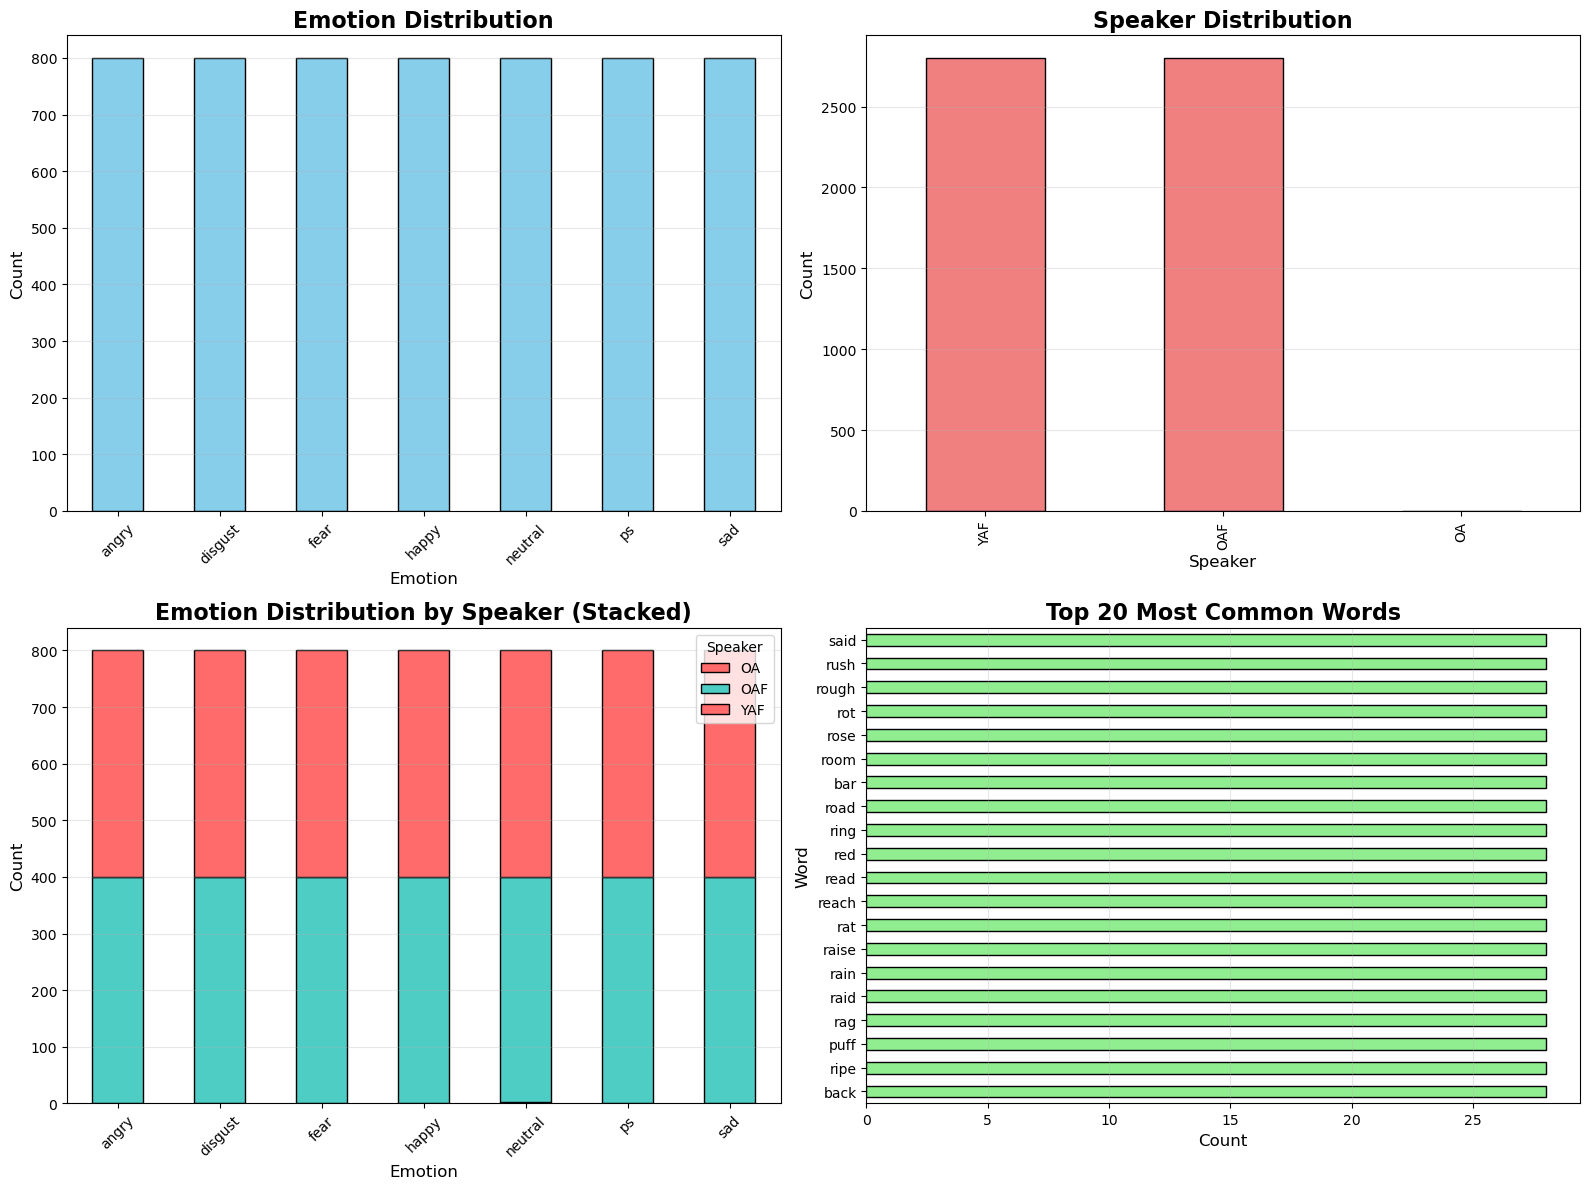

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df['emotion'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Emotion Distribution', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Emotion', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

df['speaker'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Speaker Distribution', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('Speaker', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

emotion_speaker = pd.crosstab(df['emotion'], df['speaker'])
emotion_speaker.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                     color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 0].set_title('Emotion Distribution by Speaker (Stacked)', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Emotion', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Speaker')
axes[1, 0].grid(axis='y', alpha=0.3)

top_words = df['word'].value_counts().head(20)
top_words.plot(kind='barh', ax=axes[1, 1], color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Top 20 Most Common Words', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Count', fontsize=12)
axes[1, 1].set_ylabel('Word', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Visualize audio waveform and spectrogram

In [194]:
def visualize_audio(file_path):
    y, sr = librosa.load(file_path, sr=None)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='blue')
    axes[0].set_title(f'Waveform: {os.path.basename(file_path)}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.3)
    
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axes[1], cmap='viridis')
    axes[1].set_title('Spectrogram', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Audio Info:")
    print(f"  Sample Rate: {sr} Hz")
    print(f"  Duration: {len(y)/sr:.2f} seconds")
    print(f"  Samples: {len(y)}")

Visualizing sample from each emotion:


Emotion: ANGRY | Speaker: YAF | Word: 'live'


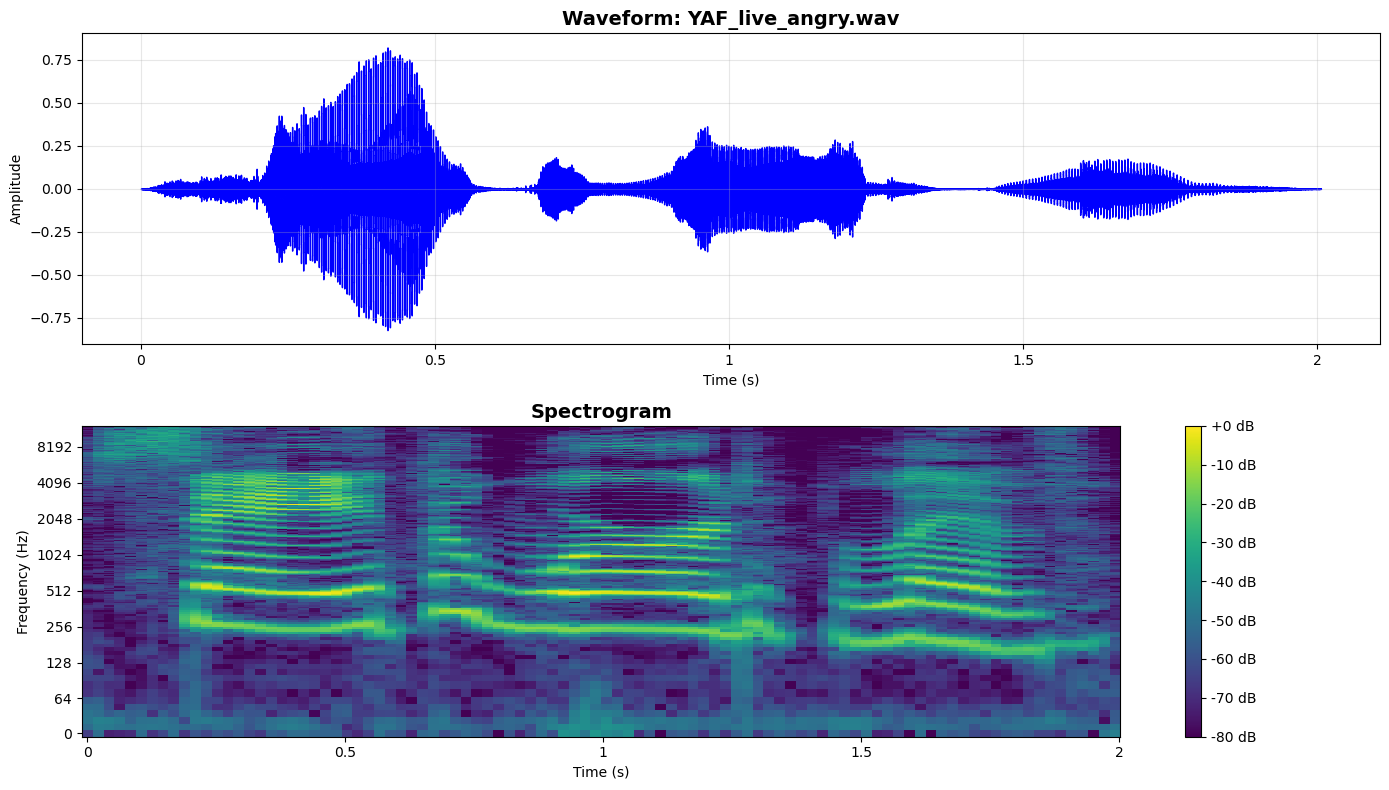

Audio Info:
  Sample Rate: 24414 Hz
  Duration: 2.01 seconds
  Samples: 48997


In [196]:
print("Visualizing sample from each emotion:\n")
for emotion in sorted(df['emotion'].unique()):
    sample = df[df['emotion'] == emotion].sample(1)
    filepath = sample['file_path'].values[0]
    word = sample['word'].values[0]
    speaker = sample['speaker'].values[0]
    
    print(f"\n{'='*70}")
    print(f"Emotion: {emotion.upper()} | Speaker: {speaker} | Word: '{word}'")
    print(f"{'='*70}")
    
    visualize_audio(filepath)
    break  # remove this to see all emotions

    Extract audio features for speech classification
    
    Returns 76 features including:
     MFCCs (13 coefficients with mean, std, max, min) = 52 features
     Spectral features (centroid, bandwidth, rolloff) = 6 features
     Zero crossing rate = 2 features  
     Chroma features (12 bands with mean, std) = 24 features
     Tempo = 1 feature
     Spectral contrast = 7 features


In [198]:
def extract_speech_features(file_path):

    try:
        # Load audio (3 seconds at 22050 Hz)
        y, sr = librosa.load(file_path, sr=22050, duration=3.0)
        
        # Pad if too short
        if len(y) < sr:
            y = np.pad(y, (0, sr - len(y)), mode='constant')
        
        features = []
        
        #  MFCCs (13 coefficients × 4 statistics = 52 features)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        features.extend(np.mean(mfccs, axis=1).flatten())  # Mean
        features.extend(np.std(mfccs, axis=1).flatten())   # Std
        features.extend(np.max(mfccs, axis=1).flatten())   # Max
        features.extend(np.min(mfccs, axis=1).flatten())   # Min
        
        #  Spectral Centroid (1 feature × 2 statistics = 2 features)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.append(float(np.mean(spectral_centroid)))
        features.append(float(np.std(spectral_centroid)))
        
        #  Spectral Bandwidth (1 feature × 2 statistics = 2 features)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features.append(float(np.mean(spectral_bandwidth)))
        features.append(float(np.std(spectral_bandwidth)))
        
        #  Spectral Rolloff (1 feature × 2 statistics = 2 features)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features.append(float(np.mean(spectral_rolloff)))
        features.append(float(np.std(spectral_rolloff)))
        
        # Zero Crossing Rate (1 feature × 2 statistics = 2 features)
        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(float(np.mean(zcr)))
        features.append(float(np.std(zcr)))
        
        #  Chroma features (12 bands × 2 statistics = 24 features)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1).flatten())
        features.extend(np.std(chroma, axis=1).flatten())
        
        #  Tempo (1 feature)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(float(tempo))
        
        #  Spectral Contrast (7 bands × 1 statistic = 7 features)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        features.extend(np.mean(contrast, axis=1).flatten())
        
        return np.array(features, dtype=float)
    
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        print(f"Error type: {type(e)}")
        import traceback
        traceback.print_exc()
        return None

In [200]:
print("TESTING SPEECH FEATURE EXTRACTION")

sample_file = df['file_path'].iloc[0]
print(f"\n Testing file: {os.path.basename(sample_file)}")

features = extract_speech_features(sample_file)

if features is not None:
    print(f"\n SUCCESS!")
    print(f"   Total features extracted: {len(features)}")
    print(f"   Feature vector shape: {features.shape}")
    print(f"   Data type: {features.dtype}")
    
    print(f"\n Feature Statistics:")
    print(f"   Mean: {np.mean(features):.4f}")
    print(f"   Std:  {np.std(features):.4f}")
    print(f"   Min:  {np.min(features):.4f}")
    print(f"   Max:  {np.max(features):.4f}")
    
    print(f"\n First 10 features:")
    for i, val in enumerate(features[:10], 1):
        print(f"   Feature {i:2d}: {val:12.6f}")
    
    if len(features) > 10:
        print(f"   ... and {len(features)-10} more features")
    
    print(f"\n Feature Breakdown (should total {len(features)}):")
    print(f"   - MFCCs (mean, std, max, min): 52 features")
    print(f"   - Spectral centroid (mean, std): 2 features")
    print(f"   - Spectral bandwidth (mean, std): 2 features")
    print(f"   - Spectral rolloff (mean, std): 2 features")
    print(f"   - Zero crossing rate (mean, std): 2 features")
    print(f"   - Chroma features (mean, std): 24 features")
    print(f"   - Tempo: 1 feature")
    print(f"   - Spectral contrast (mean): 7 features")
    print(f"   {'='*40}")
    print(f"   TOTAL: {len(features)} features")
    
else:
    print("\n Feature extraction failed")

# Optional: Test with a small segment to debug
print("DEBUG: Testing with a tiny audio segment")

try:
    # Load just a small piece to test
    y_test, sr_test = librosa.load(sample_file, sr=22050, duration=1.0)
    print(f" Audio loaded successfully")
    print(f"   Audio shape: {y_test.shape}")
    print(f"   Sample rate: {sr_test}")
    print(f"   Duration: {len(y_test)/sr_test:.2f} seconds")
except Exception as e:
    print(f" Error loading audio: {e}")

TESTING SPEECH FEATURE EXTRACTION

 Testing file: OAF_back_angry.wav

 SUCCESS!
   Total features extracted: 92
   Feature vector shape: (92,)
   Data type: float64

 Feature Statistics:
   Mean: 119.7815
   Std:  543.9431
   Min:  -601.3875
   Max:  3541.0870

 First 10 features:
   Feature  1:  -383.432617
   Feature  2:    52.460808
   Feature  3:   -17.608944
   Feature  4:   -11.810310
   Feature  5:    -4.707630
   Feature  6:     7.513891
   Feature  7:   -25.082638
   Feature  8:    -6.948460
   Feature  9:   -10.093306
   Feature 10:    -3.254936
   ... and 82 more features

 Feature Breakdown (should total 92):
   - MFCCs (mean, std, max, min): 52 features
   - Spectral centroid (mean, std): 2 features
   - Spectral bandwidth (mean, std): 2 features
   - Spectral rolloff (mean, std): 2 features
   - Zero crossing rate (mean, std): 2 features
   - Chroma features (mean, std): 24 features
   - Tempo: 1 feature
   - Spectral contrast (mean): 7 features
   TOTAL: 92 features
DEBU

C:\Users\vivek\AppData\Local\Temp\ipykernel_1960\3355850082.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features.append(float(tempo))


In [204]:
print("Extracting speech features from all audio files...")

speech_features_list = []
labels_list = []
words_list = []
failed_files = []

for idx, row in df.iterrows():
    if idx % 500 == 0:
        print(f"Processing: {idx}/{len(df)} files...")
    
    features = extract_speech_features(row['file_path'])
    
    if features is not None:
        speech_features_list.append(features)
        labels_list.append(row['emotion'])
        words_list.append(row['word'])
    else:
        failed_files.append(row['file_path'])

print(f"\n Feature extraction complete!")
print(f"  Successfully processed: {len(speech_features_list)} files")
print(f"  Failed: {len(failed_files)} files")

Extracting speech features from all audio files...
Processing: 0/5600 files...


C:\Users\vivek\AppData\Local\Temp\ipykernel_1960\3355850082.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features.append(float(tempo))


Processing: 500/5600 files...
Processing: 1000/5600 files...
Processing: 1500/5600 files...
Processing: 2000/5600 files...
Processing: 2500/5600 files...
Processing: 3000/5600 files...
Processing: 3500/5600 files...
Processing: 4000/5600 files...
Processing: 4500/5600 files...
Processing: 5000/5600 files...
Processing: 5500/5600 files...

 Feature extraction complete!
  Successfully processed: 5600 files
  Failed: 0 files


In [212]:
X_speech = np.array(speech_features_list)
y_labels = np.array(labels_list)
text_data = np.array(words_list)

print(f"  Speech features (X_speech): {X_speech.shape}")
print(f"  Labels (y_labels): {y_labels.shape}")
print(f"  Text data: {text_data.shape}")

  Speech features (X_speech): (5600, 92)
  Labels (y_labels): (5600,)
  Text data: (5600,)


In [224]:
print(f"  Labels (y_labels): {y_labels}")

  Labels (y_labels): ['angry' 'angry' 'angry' ... 'sad' 'sad' 'sad']


In [226]:
print(f"  Text data: {text_data}")

  Text data: ['back' 'bar' 'base' ... 'yes' 'young' 'youth']


In [228]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print("Label Encoding:")
for idx, emotion in enumerate(label_encoder.classes_):
    print(f"  {emotion}: {idx}")

Label Encoding:
  angry: 0
  disgust: 1
  fear: 2
  happy: 3
  neutral: 4
  ps: 5
  sad: 6


In [230]:
from sklearn.model_selection import train_test_split
X_train_speech, X_test_speech, y_train, y_test = train_test_split(
    X_speech, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [234]:
X_train_speech.shape

(4480, 92)

In [236]:
X_test_speech.shape

(1120, 92)

In [238]:
for emotion, count in zip(*np.unique(y_train, return_counts=True)):
    emotion_name = label_encoder.inverse_transform([emotion])[0]
    print(f"    {emotion_name}: {count}")

    angry: 640
    disgust: 640
    fear: 640
    happy: 640
    neutral: 640
    ps: 640
    sad: 640


In [240]:
scaler = StandardScaler()
X_train_speech_scaled = scaler.fit_transform(X_train_speech)
X_test_speech_scaled = scaler.transform(X_test_speech)

In [260]:
print(f"\nBefore scaling - Training data:")
print(f"  Mean: {X_train_speech.mean():.4f}")
print(f"  Std: {X_train_speech.std():.4f}")

print(f"\nAfter scaling - Training data:")
print(f"  Mean: {X_train_speech_scaled.mean():.4f}")
print(f"  Std: {X_train_speech_scaled.std():.4f}")


Before scaling - Training data:
  Mean: 148.1253
  Std: 675.2421

After scaling - Training data:
  Mean: 0.0000
  Std: 1.0000


In [332]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

models = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'LightGBM': LGBMClassifier(n_estimators=100,learning_rate=0.1,random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42,eval_metric='logloss')
}
results = {}

In [334]:
for model_name, model in models.items():
    print(f"Training {model_name}")
    
    model.fit(X_train_speech_scaled, y_train)
    
    y_pred_train = model.predict(X_train_speech_scaled)
    y_pred_test = model.predict(X_test_speech_scaled)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    results[model_name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'y_pred_test': y_pred_test
    }
    
    print(f" {model_name} training complete!")
    print(f"  Training Accuracy: {train_acc*100:.2f}%")
    print(f"  Testing Accuracy: {test_acc*100:.2f}%")

Training SVM
 SVM training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 100.00%
Training Random Forest
 Random Forest training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 100.00%
Training Logistic Regression
 Logistic Regression training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 99.64%
Training Naive Bayes
 Naive Bayes training complete!
  Training Accuracy: 91.74%
  Testing Accuracy: 91.61%
Training LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004596 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23251
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 92
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training fro

In [335]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy (%)': [results[m]['train_accuracy']*100 for m in results.keys()],
    'Test Accuracy (%)': [results[m]['test_accuracy']*100 for m in results.keys()]
})

print("\nModel Comparison Table:")

print(comparison_df.to_string(index=False))


Model Comparison Table:
              Model  Train Accuracy (%)  Test Accuracy (%)
                SVM          100.000000         100.000000
      Random Forest          100.000000         100.000000
Logistic Regression          100.000000          99.642857
        Naive Bayes           91.741071          91.607143
           LightGBM          100.000000         100.000000
            XGBoost          100.000000         100.000000


## TEXT-ONLY EMOTION RECOGNITION PIPELINE

In [349]:

_, _, text_train, text_test = train_test_split(
    X_speech, text_data, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"  Training samples: {len(text_train)}")
print(f"  Testing samples: {len(text_test)}")

  Training samples: 4480
  Testing samples: 1120


In [351]:
print(f"\n Sample training texts:")
for i in range(10):
    print(f"  {i+1}. '{text_train[i]}' -> {label_encoder.inverse_transform([y_train[i]])[0]}")


 Sample training texts:
  1. 'fit' -> disgust
  2. 'week' -> disgust
  3. 'doll' -> happy
  4. 'luck' -> ps
  5. 'voice' -> disgust
  6. 'pain' -> angry
  7. 'note' -> happy
  8. 'cause' -> sad
  9. 'chair' -> disgust
  10. 'when' -> sad


In [373]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create TF-IDF vectorizer
# TF-IDF converts text to numerical features based on word importance
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,      # Use top 100 most important words
    ngram_range=(1, 2),    # Use single words and word pairs
    lowercase=True,
    analyzer='char',       # Character-level analysis (good for short words)
    max_df=0.9,           # Ignore words that appear in >90% of documents
    min_df=2              # Ignore words that appear in <2 documents
)

In [377]:
X_train_text = tfidf_vectorizer.fit_transform(text_train).toarray()

X_test_text = tfidf_vectorizer.transform(text_test).toarray()

print(f"\n Text features extracted!")
print(f"  Training shape: {X_train_text.shape}")
print(f"  Testing shape: {X_test_text.shape}")
print(f"  Number of features: {X_train_text.shape[1]}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n Top 20 TF-IDF features:")
for i in range(min(20, len(feature_names))):
    print(f"  {i+1}. '{feature_names[i]}'")


 Text features extracted!
  Training shape: (4480, 100)
  Testing shape: (1120, 100)
  Number of features: 100

 Top 20 TF-IDF features:
  1. 'a'
  2. 'ac'
  3. 'ad'
  4. 'ag'
  5. 'ai'
  6. 'al'
  7. 'am'
  8. 'ap'
  9. 'ar'
  10. 'as'
  11. 'at'
  12. 'b'
  13. 'ba'
  14. 'bo'
  15. 'c'
  16. 'ca'
  17. 'ce'
  18. 'ch'
  19. 'ck'
  20. 'd'


In [379]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=50,       # Use top 50 most common words
    ngram_range=(1, 1),    # Use only single words
    lowercase=True
)

X_train_text_count = count_vectorizer.fit_transform(text_train).toarray()
X_test_text_count = count_vectorizer.transform(text_test).toarray()

print(f"\n Word frequency features extracted!")
print(f"  Training shape: {X_train_text_count.shape}")
print(f"  Testing shape: {X_test_text_count.shape}")


 Word frequency features extracted!
  Training shape: (4480, 50)
  Testing shape: (1120, 50)


In [381]:
vocab = count_vectorizer.get_feature_names_out()
print(f"\n Vocabulary (first 30 words):")
print(f"  {list(vocab[:30])}")


 Vocabulary (first 30 words):
  ['bean', 'bone', 'cause', 'dip', 'fat', 'gap', 'get', 'gin', 'good', 'gun', 'hall', 'hash', 'hate', 'jail', 'jar', 'join', 'jug', 'knock', 'learn', 'long', 'lot', 'love', 'match', 'mode', 'name', 'neat', 'rag', 'raise', 'rat', 'reach']


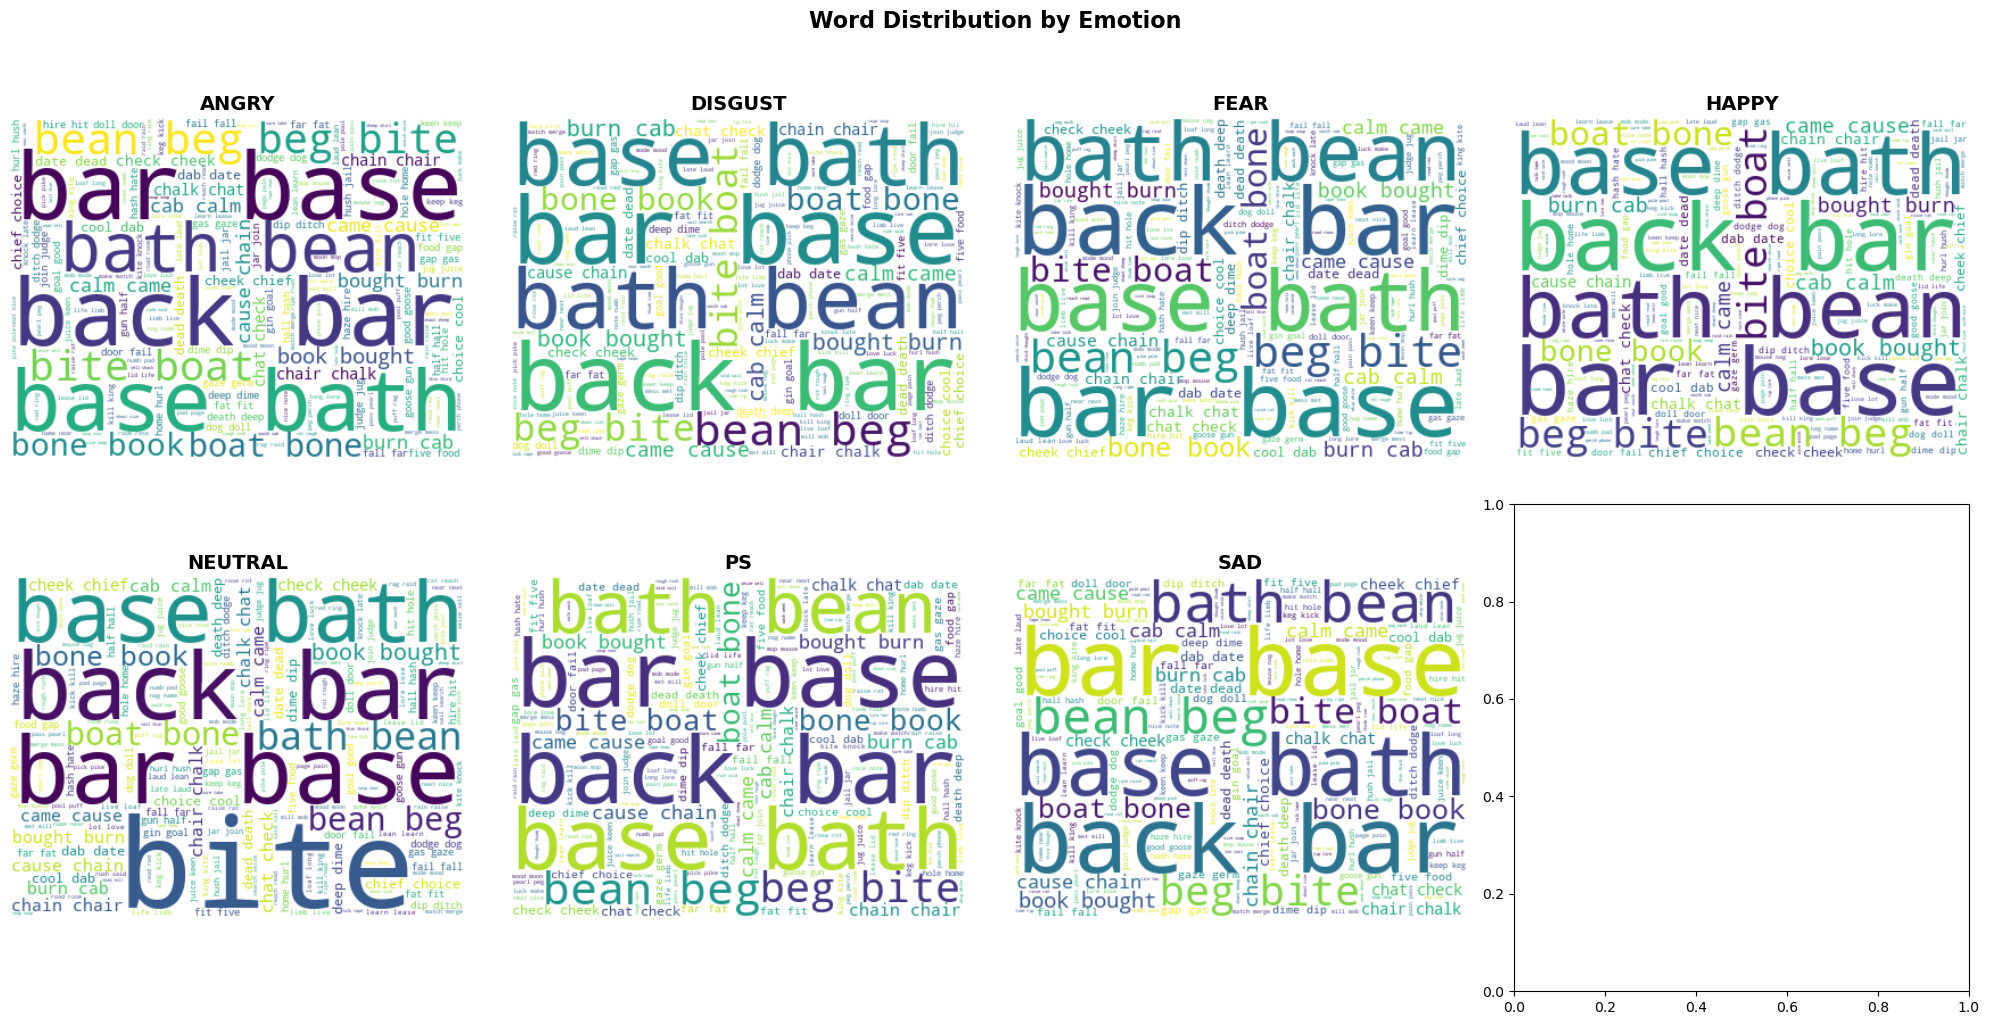

In [383]:
from collections import Counter


emotion_words = {}
for emotion in label_encoder.classes_:
    emotion_mask = (y_labels == emotion)
    words = text_data[emotion_mask]
    emotion_words[emotion] = ' '.join(words)

from wordcloud import WordCloud

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, emotion in enumerate(sorted(label_encoder.classes_)):
    if idx < len(axes):
        wordcloud = WordCloud(width=400, height=300, 
                             background_color='white',
                             colormap='viridis').generate(emotion_words[emotion])
        
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{emotion.upper()}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Word Distribution by Emotion', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [384]:
text_models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

text_results = {}

In [387]:
for model_name, model in text_models.items():
    model.fit(X_train_text, y_train)
    
    y_pred_train = model.predict(X_train_text)
    y_pred_test = model.predict(X_test_text)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    text_results[model_name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'y_pred_test': y_pred_test
    }
    
    print(f" {model_name} training complete!")
    print(f"  Training Accuracy: {train_acc*100:.2f}%")
    print(f"  Testing Accuracy: {test_acc*100:.2f}%")

 Naive Bayes training complete!
  Training Accuracy: 16.74%
  Testing Accuracy: 4.46%
 Logistic Regression training complete!
  Training Accuracy: 16.92%
  Testing Accuracy: 3.75%
 SVM training complete!
  Training Accuracy: 16.67%
  Testing Accuracy: 4.73%
 Random Forest training complete!
  Training Accuracy: 17.77%
  Testing Accuracy: 0.36%


In [391]:
text_comparison_df = pd.DataFrame({
    'Model': list(text_results.keys()),
    'Train Accuracy (%)': [text_results[m]['train_accuracy']*100 for m in text_results.keys()],
    'Test Accuracy (%)': [text_results[m]['test_accuracy']*100 for m in text_results.keys()]
})

print("\nText-Only Model Comparison Table:")
print(text_comparison_df.to_string(index=False))

best_text_model_name = text_comparison_df.loc[text_comparison_df['Test Accuracy (%)'].idxmax(), 'Model']
best_text_test_acc = text_comparison_df['Test Accuracy (%)'].max()


Text-Only Model Comparison Table:
              Model  Train Accuracy (%)  Test Accuracy (%)
        Naive Bayes           16.741071           4.464286
Logistic Regression           16.919643           3.750000
                SVM           16.674107           4.732143
      Random Forest           17.767857           0.357143


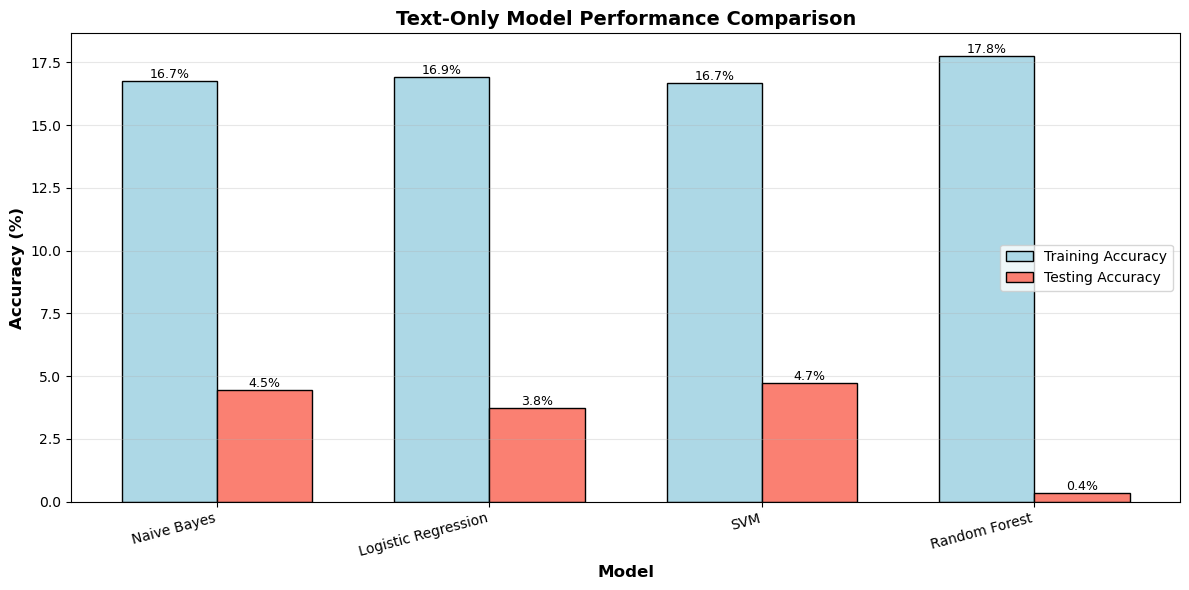

In [393]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(text_comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, text_comparison_df['Train Accuracy (%)'], width, 
               label='Training Accuracy', color='lightblue', edgecolor='black')
bars2 = ax.bar(x + width/2, text_comparison_df['Test Accuracy (%)'], width, 
               label='Testing Accuracy', color='salmon', edgecolor='black')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Text-Only Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(text_comparison_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [399]:
best_text_model = text_results[best_text_model_name]['model']
y_pred_text_best = text_results[best_text_model_name]['y_pred_test']

print(f"\nDetailed Classification Report for {best_text_model_name} (Text-Only):")

text_report = classification_report(
    y_test, 
    y_pred_text_best, 
    target_names=label_encoder.classes_,
    digits=3
)
print(text_report)

print("\nPer-Emotion Accuracy (Text-Only):")
text_emotion_accs = []
for emotion_idx, emotion_name in enumerate(label_encoder.classes_):
    mask = (y_test == emotion_idx)
    if mask.sum() > 0:
        emotion_acc = accuracy_score(y_test[mask], y_pred_text_best[mask])
        text_emotion_accs.append({
            'Emotion': emotion_name,
            'Accuracy (%)': emotion_acc * 100
        })
        print(f"  {emotion_name:15s}: {emotion_acc*100:.2f}%")

text_emotion_acc_df = pd.DataFrame(text_emotion_accs).sort_values('Accuracy (%)', ascending=False)


Detailed Classification Report for SVM (Text-Only):
              precision    recall  f1-score   support

       angry      0.022     0.019     0.020       160
     disgust      0.034     0.031     0.032       160
        fear      0.079     0.069     0.074       160
       happy      0.054     0.069     0.060       160
     neutral      0.053     0.075     0.062       160
          ps      0.066     0.062     0.064       160
         sad      0.009     0.006     0.007       160

    accuracy                          0.047      1120
   macro avg      0.045     0.047     0.046      1120
weighted avg      0.045     0.047     0.046      1120


Per-Emotion Accuracy (Text-Only):
  angry          : 1.88%
  disgust        : 3.12%
  fear           : 6.88%
  happy          : 6.88%
  neutral        : 7.50%
  ps             : 6.25%
  sad            : 0.62%


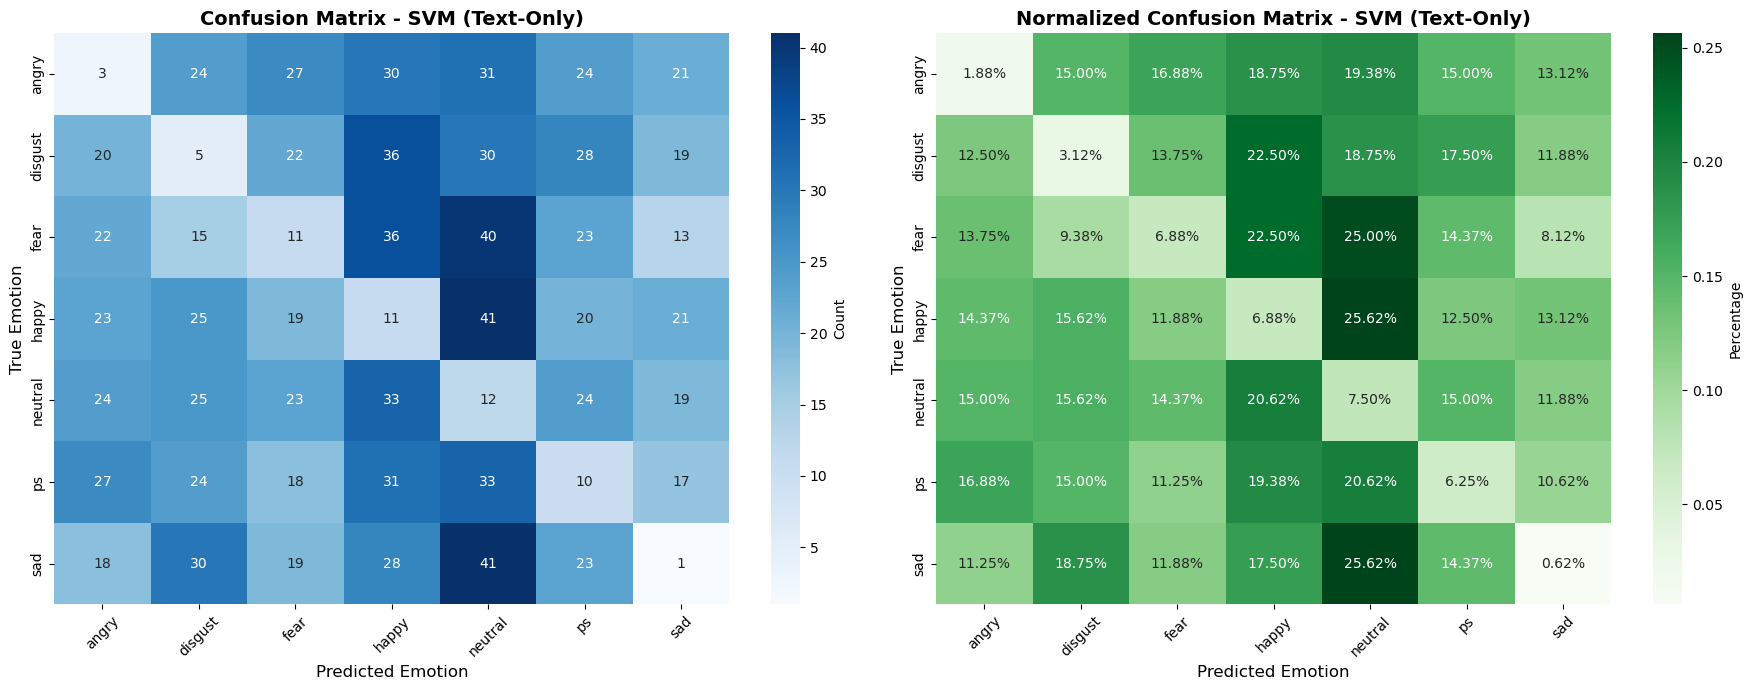

In [403]:
cm_text = confusion_matrix(y_test, y_pred_text_best)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_text_model_name} (Text-Only)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Emotion', fontsize=12)
axes[0].set_ylabel('True Emotion', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_text_normalized = cm_text.astype('float') / cm_text.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_text_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Percentage'},
            ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix - {best_text_model_name} (Text-Only)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion', fontsize=12)
axes[1].set_ylabel('True Emotion', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [407]:
print("Text-Only Error Analysis:")

text_misclassified_mask = (y_test != y_pred_text_best)
text_misclassified_indices = np.where(text_misclassified_mask)[0]

print(f"\nTotal misclassified: {len(text_misclassified_indices)} out of {len(y_test)}")
print(f"Misclassification rate: {len(text_misclassified_indices)/len(y_test)*100:.2f}%")

print("\nFirst 15 Misclassified Examples:")

for i, idx in enumerate(text_misclassified_indices[:15]):
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred_text_best[idx]])[0]
    word = text_test[idx]
    
    print(f"\n{i+1}. Word: '{word}'")
    print(f"   True Emotion: {true_label}")
    print(f"   Predicted: {pred_label}")

Text-Only Error Analysis:

Total misclassified: 1067 out of 1120
Misclassification rate: 95.27%

First 15 Misclassified Examples:

1. Word: 'home'
   True Emotion: fear
   Predicted: sad

2. Word: 'mess'
   True Emotion: ps
   Predicted: fear

3. Word: 'mill'
   True Emotion: angry
   Predicted: fear

4. Word: 'which'
   True Emotion: ps
   Predicted: neutral

5. Word: 'tough'
   True Emotion: angry
   Predicted: disgust

6. Word: 'thumb'
   True Emotion: disgust
   Predicted: sad

7. Word: 'bite'
   True Emotion: ps
   Predicted: neutral

8. Word: 'tape'
   True Emotion: angry
   Predicted: sad

9. Word: 'whip'
   True Emotion: ps
   Predicted: neutral

10. Word: 'five'
   True Emotion: disgust
   Predicted: happy

11. Word: 'such'
   True Emotion: sad
   Predicted: neutral

12. Word: 'vote'
   True Emotion: sad
   Predicted: happy

13. Word: 'doll'
   True Emotion: angry
   Predicted: ps

14. Word: 'pain'
   True Emotion: disgust
   Predicted: angry

15. Word: 'late'
   True Emotion:

In [409]:
if hasattr(best_text_model, 'feature_importances_'):
    print("Top 20 Most Important Features (Words/N-grams):")
    
    importances = best_text_model.feature_importances_
    indices = np.argsort(importances)[-20:][::-1]
    
    for i, idx in enumerate(indices):
        print(f"  {i+1}. '{feature_names[idx]}': {importances[idx]:.4f}")

elif hasattr(best_text_model, 'coef_'):
    print("Top Words per Emotion Class:")
    print("="*70)
    
    for idx, emotion in enumerate(label_encoder.classes_):
        print(f"\n{emotion.upper()}:")
        coef = best_text_model.coef_[idx]
        top_indices = np.argsort(coef)[-10:][::-1]
        
        for i, word_idx in enumerate(top_indices):
            print(f"  {i+1}. '{feature_names[word_idx]}': {coef[word_idx]:.4f}")

Top Words per Emotion Class:

ANGRY:
  1. 'ng': 1.5043
  2. 'sh': 1.3041
  3. 'fa': 1.2471
  4. 'wi': 1.1775
  5. 'ai': 1.1689
  6. 'ol': 1.1598
  7. 'us': 1.1567
  8. 'rn': 1.1073
  9. 'bo': 1.0849
  10. 'th': 1.0741

DISGUST:
  1. 'bo': 1.5467
  2. 'ee': 1.4693
  3. 'ic': 1.3859
  4. 'p': 1.2974
  5. 'ng': 1.2456
  6. 'us': 1.2454
  7. 're': 1.2027
  8. 'as': 1.1733
  9. 'ip': 1.0390
  10. 'wi': 0.9943

FEAR:
  1. 'ou': 1.2767
  2. 'us': 1.2429
  3. 'bo': 1.2308
  4. 'ch': 1.1539
  5. 'so': 1.1036
  6. 'ng': 1.0594
  7. 'he': 1.0000
  8. 'll': 0.9357
  9. 'ra': 0.8622
  10. 'sh': 0.8598

HAPPY:
  1. 'us': 1.8259
  2. 'at': 1.5219
  3. 'as': 1.4502
  4. 'o': 1.1390
  5. 'le': 1.0411
  6. 'do': 1.0331
  7. 'rn': 1.0317
  8. 'ke': 0.9806
  9. 'ic': 0.9617
  10. 'th': 0.9455

NEUTRAL:
  1. 'n': 1.8388
  2. 'p': 1.5765
  3. 'te': 1.3399
  4. 'sh': 1.3113
  5. 'v': 1.1563
  6. 've': 1.0880
  7. 'ch': 1.0704
  8. 'ic': 1.0334
  9. 'rn': 1.0246
  10. 'bo': 0.8938

PS:
  1. 'sh': 1.3384
  2. 

SPEECH vs TEXT COMPARISON

    Pipeline Best Model  Test Accuracy (%)
Speech-Only        SVM         100.000000
  Text-Only        SVM           4.732143


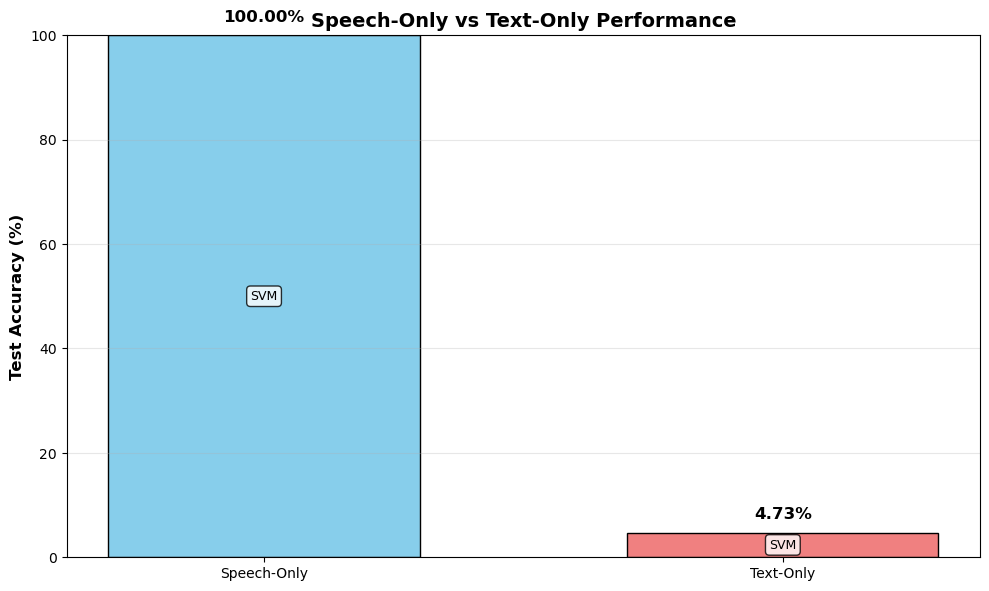


 Speech-only performs better by 95.27%
   → Audio features (tone, pitch, etc.) are more informative for emotion recognition


In [413]:
print("SPEECH vs TEXT COMPARISON")

comparison_speech_text = pd.DataFrame({
    'Pipeline': ['Speech-Only', 'Text-Only'],
    'Best Model': [best_model_name, best_text_model_name],
    'Test Accuracy (%)': [best_test_acc, best_text_test_acc]
})

print("\n", comparison_speech_text.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

pipelines = comparison_speech_text['Pipeline']
accuracies = comparison_speech_text['Test Accuracy (%)']
colors = ['skyblue', 'lightcoral']

bars = ax.bar(pipelines, accuracies, color=colors, edgecolor='black', width=0.6)

ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Speech-Only vs Text-Only Performance', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

for i, (bar, model) in enumerate(zip(bars, comparison_speech_text['Best Model'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            f'{model}',
            ha='center', va='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

if best_test_acc > best_text_test_acc:
    diff = best_test_acc - best_text_test_acc
    print(f"\n Speech-only performs better by {diff:.2f}%")
    print("   → Audio features (tone, pitch, etc.) are more informative for emotion recognition")
else:
    diff = best_text_test_acc - best_test_acc
    print(f"\n Text-only performs better by {diff:.2f}%")
    print("   → Word content is more informative for emotion recognition")

In [420]:
print("TEXT-ONLY PIPELINE SUMMARY")

print(f"\n Dataset:")
print(f"   Training samples: {len(text_train)}")
print(f"   Testing samples: {len(text_test)}")
print(f"   Number of TF-IDF features: {X_train_text.shape[1]}")
print(f"   Vocabulary size: {len(feature_names)}")

print(f"\n Models Trained:")
for model_name in text_models.keys():
    print(f"   • {model_name}")

print(f"\n Best Model: {best_text_model_name}")
print(f"   Test Accuracy: {best_text_test_acc:.2f}%")

print(f"\n Top 3 Best Classified Emotions:")
for i in range(min(3, len(text_emotion_acc_df))):
    row = text_emotion_acc_df.iloc[i]
    print(f"   {i+1}. {row['Emotion']}: {row['Accuracy (%)']:.2f}%")

print(f"\n Top 3 Worst Classified Emotions:")
for i in range(min(3, len(text_emotion_acc_df))):
    row = text_emotion_acc_df.iloc[-(i+1)]
    print(f"   {i+1}. {row['Emotion']}: {row['Accuracy (%)']:.2f}%")

print(f"\n Text-only pipeline complete!")


TEXT-ONLY PIPELINE SUMMARY

 Dataset:
   Training samples: 4480
   Testing samples: 1120
   Number of TF-IDF features: 100
   Vocabulary size: 100

 Models Trained:
   • Naive Bayes
   • Logistic Regression
   • SVM
   • Random Forest

 Best Model: SVM
   Test Accuracy: 4.73%

 Top 3 Best Classified Emotions:
   1. neutral: 7.50%
   2. fear: 6.88%
   3. happy: 6.88%

 Top 3 Worst Classified Emotions:
   1. sad: 0.62%
   2. angry: 1.88%
   3. disgust: 3.12%

 Text-only pipeline complete!


## FUSION (MULTIMODAL) EMOTION RECOGNITION PIPELINE

In [425]:
print("EARLY FUSION: Concatenating Speech and Text Features")

X_train_fusion = np.concatenate([X_train_speech_scaled, X_train_text], axis=1)
X_test_fusion = np.concatenate([X_test_speech_scaled, X_test_text], axis=1)

print(f"\nFeature Dimensions:")
print(f"  Speech features: {X_train_speech_scaled.shape[1]}")
print(f"  Text features: {X_train_text.shape[1]}")
print(f"  Combined features: {X_train_fusion.shape[1]}")

print(f"\nDataset Shapes:")
print(f"  Training set: {X_train_fusion.shape}")
print(f"  Testing set: {X_test_fusion.shape}")

EARLY FUSION: Concatenating Speech and Text Features

Feature Dimensions:
  Speech features: 92
  Text features: 100
  Combined features: 192

Dataset Shapes:
  Training set: (4480, 192)
  Testing set: (1120, 192)


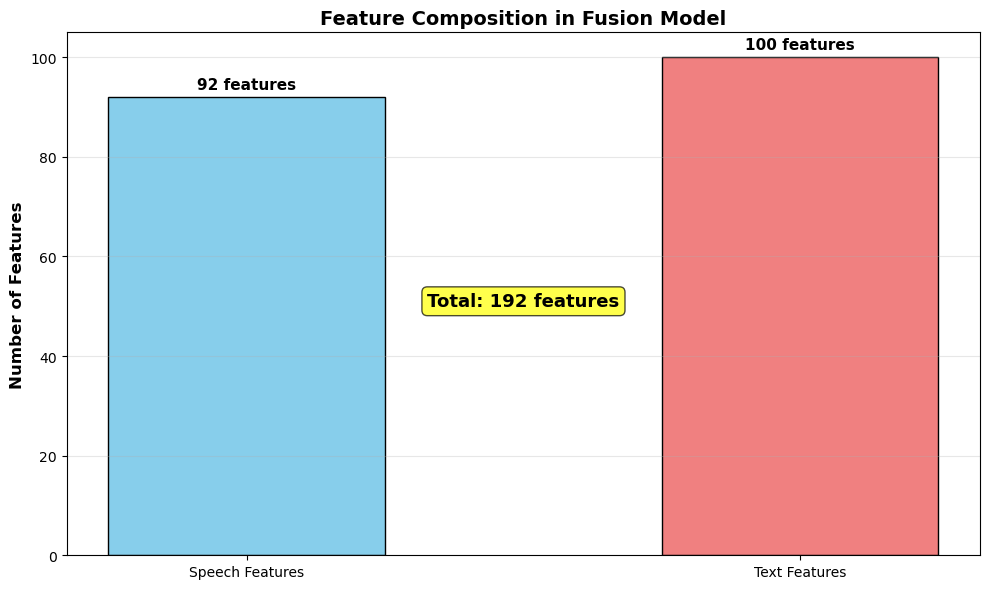

In [427]:
fig, ax = plt.subplots(figsize=(10, 6))

feature_sources = ['Speech Features', 'Text Features']
feature_counts = [X_train_speech_scaled.shape[1], X_train_text.shape[1]]
colors = ['skyblue', 'lightcoral']

bars = ax.bar(feature_sources, feature_counts, color=colors, edgecolor='black', width=0.5)

ax.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Composition in Fusion Model', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(height)} features',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

total_features = sum(feature_counts)
ax.text(0.5, max(feature_counts) * 0.5, 
        f'Total: {total_features} features',
        ha='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

In [429]:
fusion_models = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB()
}

fusion_results = {}

for model_name, model in fusion_models.items():
    print(f"\n{'='*70}")
    print(f"Training {model_name} on fused features...")
    print(f"{'='*70}")
    
    
    model.fit(X_train_fusion, y_train)
    
    y_pred_train = model.predict(X_train_fusion)
    y_pred_test = model.predict(X_test_fusion)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    fusion_results[model_name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'y_pred_test': y_pred_test
    }
    
    print(f" {model_name} training complete!")
    print(f"  Training Accuracy: {train_acc*100:.2f}%")
    print(f"  Testing Accuracy: {test_acc*100:.2f}%")


Training SVM on fused features...
 SVM training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 100.00%

Training Random Forest on fused features...
 Random Forest training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 100.00%

Training Logistic Regression on fused features...
 Logistic Regression training complete!
  Training Accuracy: 100.00%
  Testing Accuracy: 99.64%

Training Naive Bayes on fused features...
 Naive Bayes training complete!
  Training Accuracy: 90.76%
  Testing Accuracy: 88.57%


In [433]:
fusion_comparison_df = pd.DataFrame({
    'Model': list(fusion_results.keys()),
    'Train Accuracy (%)': [fusion_results[m]['train_accuracy']*100 for m in fusion_results.keys()],
    'Test Accuracy (%)': [fusion_results[m]['test_accuracy']*100 for m in fusion_results.keys()]
})

print("\nFusion (Multimodal) Model Comparison Table:")
print(fusion_comparison_df.to_string(index=False))

best_fusion_model_name = fusion_comparison_df.loc[fusion_comparison_df['Test Accuracy (%)'].idxmax(), 'Model']
best_fusion_test_acc = fusion_comparison_df['Test Accuracy (%)'].max()


Fusion (Multimodal) Model Comparison Table:
              Model  Train Accuracy (%)  Test Accuracy (%)
                SVM          100.000000         100.000000
      Random Forest          100.000000         100.000000
Logistic Regression          100.000000          99.642857
        Naive Bayes           90.758929          88.571429


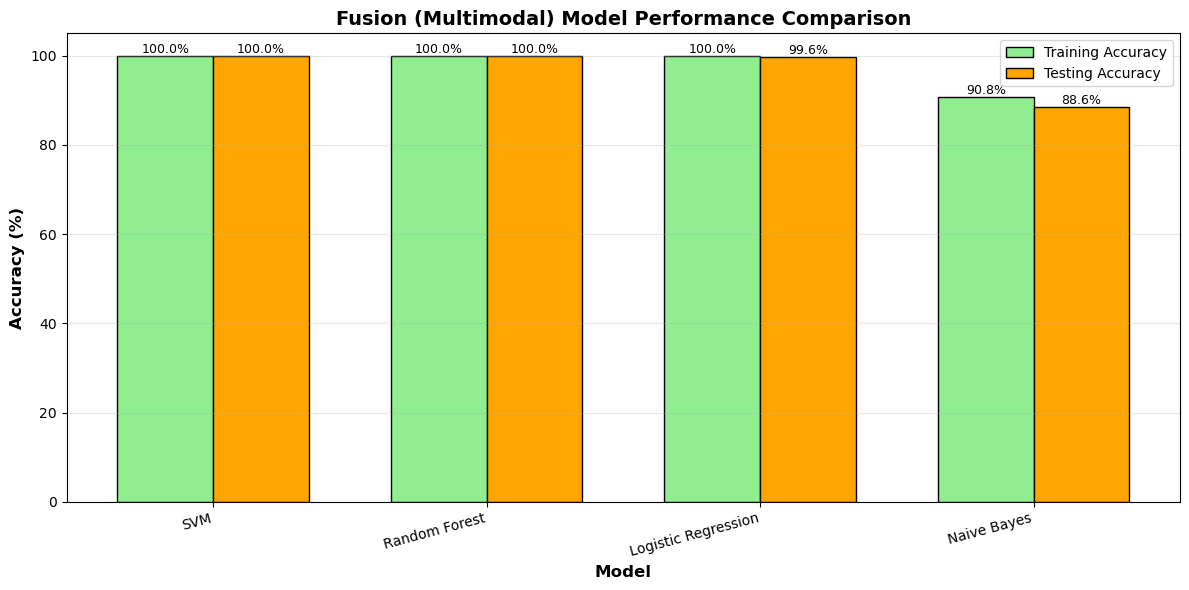

In [435]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fusion_comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, fusion_comparison_df['Train Accuracy (%)'], width, 
               label='Training Accuracy', color='lightgreen', edgecolor='black')
bars2 = ax.bar(x + width/2, fusion_comparison_df['Test Accuracy (%)'], width, 
               label='Testing Accuracy', color='orange', edgecolor='black')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Fusion (Multimodal) Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fusion_comparison_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [437]:
best_fusion_model = fusion_results[best_fusion_model_name]['model']
y_pred_fusion_best = fusion_results[best_fusion_model_name]['y_pred_test']

print(f"\nDetailed Classification Report for {best_fusion_model_name} (Fusion):")

fusion_report = classification_report(
    y_test, 
    y_pred_fusion_best, 
    target_names=label_encoder.classes_,
    digits=3
)
print(fusion_report)

print("\nPer-Emotion Accuracy (Fusion):")
fusion_emotion_accs = []
for emotion_idx, emotion_name in enumerate(label_encoder.classes_):
    mask = (y_test == emotion_idx)
    if mask.sum() > 0:
        emotion_acc = accuracy_score(y_test[mask], y_pred_fusion_best[mask])
        fusion_emotion_accs.append({
            'Emotion': emotion_name,
            'Accuracy (%)': emotion_acc * 100
        })
        print(f"  {emotion_name:15s}: {emotion_acc*100:.2f}%")

fusion_emotion_acc_df = pd.DataFrame(fusion_emotion_accs).sort_values('Accuracy (%)', ascending=False)


Detailed Classification Report for SVM (Fusion):
              precision    recall  f1-score   support

       angry      1.000     1.000     1.000       160
     disgust      1.000     1.000     1.000       160
        fear      1.000     1.000     1.000       160
       happy      1.000     1.000     1.000       160
     neutral      1.000     1.000     1.000       160
          ps      1.000     1.000     1.000       160
         sad      1.000     1.000     1.000       160

    accuracy                          1.000      1120
   macro avg      1.000     1.000     1.000      1120
weighted avg      1.000     1.000     1.000      1120


Per-Emotion Accuracy (Fusion):
  angry          : 100.00%
  disgust        : 100.00%
  fear           : 100.00%
  happy          : 100.00%
  neutral        : 100.00%
  ps             : 100.00%
  sad            : 100.00%


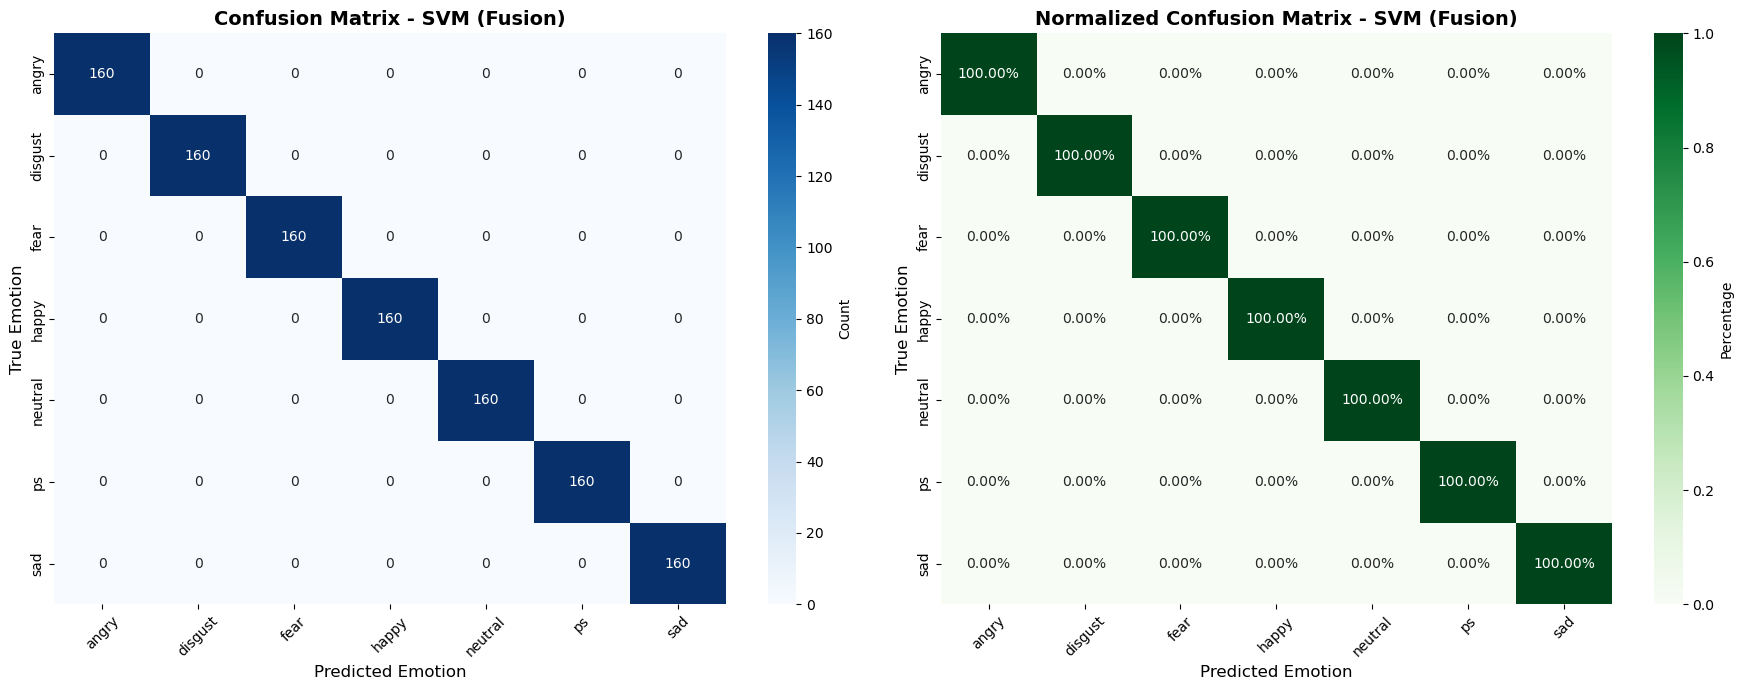

In [439]:
cm_fusion = confusion_matrix(y_test, y_pred_fusion_best)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_fusion_model_name} (Fusion)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Emotion', fontsize=12)
axes[0].set_ylabel('True Emotion', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_fusion_normalized = cm_fusion.astype('float') / cm_fusion.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_fusion_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Percentage'},
            ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix - {best_fusion_model_name} (Fusion)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion', fontsize=12)
axes[1].set_ylabel('True Emotion', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [455]:
print(f"   Total audio files: {len(audio_files)}")
print(f"   Training samples: {len(X_train_speech)}")
print(f"   Testing samples: {len(X_test_speech)}")
print(f"   Number of emotions: {len(label_encoder.classes_)}")
print(f"   Emotions: {list(label_encoder.classes_)}")

print(f"\n SPEECH-ONLY PIPELINE:")
print(f"   Best Model: {best_model_name}")
print(f"   Test Accuracy: {best_test_acc:.2f}%")
print(f"   Features: {X_train_speech_scaled.shape[1]} audio features")

print(f"\n TEXT-ONLY PIPELINE:")
print(f"   Best Model: {best_text_model_name}")
print(f"   Test Accuracy: {best_text_test_acc:.2f}%")
print(f"   Features: {X_train_text.shape[1]} TF-IDF features")

print(f"\n FUSION (MULTIMODAL) PIPELINE:")
print(f"   Best Model: {best_fusion_model_name}")
print(f"   Test Accuracy: {best_fusion_test_acc:.2f}%")
print(f"   Features: {X_train_fusion.shape[1]} combined features")

   Total audio files: 5600
   Training samples: 4480
   Testing samples: 1120
   Number of emotions: 7
   Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

 SPEECH-ONLY PIPELINE:
   Best Model: SVM
   Test Accuracy: 100.00%
   Features: 92 audio features

 TEXT-ONLY PIPELINE:
   Best Model: SVM
   Test Accuracy: 4.73%
   Features: 100 TF-IDF features

 FUSION (MULTIMODAL) PIPELINE:
   Best Model: SVM
   Test Accuracy: 100.00%
   Features: 192 combined features


In [459]:
print("SAVING DATA FOR DEEP LEARNING APPROACH")

os.makedirs('../results', exist_ok=True)

np.save('../results/X_speech.npy', X_speech)
print("Saved: X_speech.npy")
print(f"  Shape: {X_speech.shape}")

np.save('../results/y_labels.npy', y_labels)
print(" Saved: y_labels.npy")
print(f"  Shape: {y_labels.shape}")

np.save('../results/text_data.npy', text_data)
print(" Saved: text_data.npy")
print(f"  Shape: {text_data.shape}")

df.to_csv('../results/dataset_info.csv', index=False)
print(" Saved: dataset_info.csv")
print(f"  Rows: {len(df)}")

print("\nSaved files:")
print("  1. ../results/X_speech.npy - Speech features")
print("  2. ../results/y_labels.npy - Emotion labels")
print("  3. ../results/text_data.npy - Spoken words")
print("  4. ../results/dataset_info.csv - Complete dataset info")

SAVING DATA FOR DEEP LEARNING APPROACH
Saved: X_speech.npy
  Shape: (5600, 92)
 Saved: y_labels.npy
  Shape: (5600,)
 Saved: text_data.npy
  Shape: (5600,)
 Saved: dataset_info.csv
  Rows: 5600

Saved files:
  1. ../results/X_speech.npy - Speech features
  2. ../results/y_labels.npy - Emotion labels
  3. ../results/text_data.npy - Spoken words
  4. ../results/dataset_info.csv - Complete dataset info
